# Telecom Customer Churn Prediction
### Binary Classification using Logistic Regression

This project predicts whether a telecom customer will **churn (leave the service)** or **stay with the company**.  
The workflow follows a complete machine learning pipeline including preprocessing, feature engineering, model training, evaluation, and visualization.

### Pipeline:
`Load → Clean → Split → Engineer → Encode → Scale →class imbalane handling→ L1 Select → CrossValidate → hyperParameterTune → Threshold → Evaluate `

# Step-1: Importing the libraries

In this step we import all the required Python libraries used throughout the project.  
These libraries help with:

- Data manipulation (**Pandas, NumPy**)
- Data visualization
- Machine learning model building (**Scikit-Learn**)
- Handling class imbalance (**SMOTE**)

In [1]:
# ── Data Handling ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)   # show all columns in df.head()
# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
# ── Suppress non-critical warnings ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
# ── Train-Test Split & Cross-Validation ────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)
# ── Model ──────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
# ── Preprocessing ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
# ── Feature Selection ──────────────────────────────────────────────────────────
from sklearn.feature_selection import SelectFromModel
# ── Evaluation Metrics ─────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,       # full precision/recall/F1 per class
    confusion_matrix,            # TP / FP / FN / TN breakdown
    roc_auc_score,               # ROC-AUC score
    roc_curve,                   # ROC curve points for plotting
    f1_score,                    # harmonic mean of precision & recall
    accuracy_score,              # overall accuracy
    recall_score,                # priority metric — catch actual churners
    precision_score,             # of predicted churners, how many were real
    precision_recall_curve,      # PR curve for threshold optimization
    average_precision_score      # PR-AUC — better metric for imbalanced data
)
# ── Imbalance Handling — SMOTE inside Pipeline (no leakage) ───────────────────
from imblearn.pipeline      import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
# ── Hyperparameter Search Distribution ─────────────────────────────────────────
from scipy.stats import loguniform   # log-uniform distribution for C tuning
# ── Global Seed ────────────────────────────────────────────────────────────────
RANDOM_STATE = 42    # fixed seed ensures reproducibility across all steps

print('All libraries imported successfully.')
print(f'  pandas     : {pd.__version__}')
print(f'  numpy      : {np.__version__}')
print(f'  sklearn    : {__import__("sklearn").__version__}')
print(f'  imblearn   : {__import__("imblearn").__version__}')

All libraries imported successfully.
  pandas     : 2.2.2
  numpy      : 1.26.4
  sklearn    : 1.5.1
  imblearn   : 0.12.3


# Step-2: Loading the dataset

The telecom customer churn dataset is loaded into a Pandas DataFrame.  
This dataset contains information about customers such as:

- Demographics
- Account information
- Services subscribed
- Monthly charges
- Churn status

The dataset is inspected to understand its structure and variables.

In [2]:
df = pd.read_csv('telecom_dataset.csv')

EXPECTED_COLS = [
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges', 'Churn'
]

missing_cols   = [c for c in EXPECTED_COLS if c not in df.columns]
extra_cols     = [c for c in df.columns if c not in EXPECTED_COLS]
duplicate_rows = df.duplicated().sum()

print("=" * 50)
print("       DATASET VALIDATION REPORT")
print("=" * 50)
print(f"  Shape           : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"  Missing cols    : {missing_cols if missing_cols else 'None'}")
print(f"  Extra cols      : {extra_cols   if extra_cols   else 'None'}")
print(f"  Duplicate rows  : {duplicate_rows}")
print(f"  Memory usage    : {df.memory_usage(deep=True).sum()/1024:.1f} KB")
print("=" * 50)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values per Column:")
mv = df.isnull().sum()
print(mv[mv > 0] if mv[mv > 0].any() else "  None — all columns complete")

print("\nChurn Distribution:")
churn_pct = df['Churn'].value_counts(normalize=True) * 100
for label, count in df['Churn'].value_counts().items():
    bar = '█' * int(churn_pct[label] / 2)
    print(f"  {label:<5}: {count:>5,}  ({churn_pct[label]:.1f}%)  {bar}")

df.head()

       DATASET VALIDATION REPORT
  Shape           : 7,043 rows x 21 columns
  Missing cols    : None
  Extra cols      : None
  Duplicate rows  : 0
  Memory usage    : 6984.7 KB

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values per Column:
  None — all columns complete

Churn Distribution:
  No   : 5,174  (73.5%)  ████████████████████████████████████
  Yes  : 1,869  (26.5%)  █████████████


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step-3: Cleaning the dataset

Before training a model, the dataset must be cleaned.

Key preprocessing steps performed:

- Removing unnecessary columns such as **customerID**
- Converting **TotalCharges** to numeric format
- Handling missing values
- Fixing data inconsistencies

These steps ensure the dataset is suitable for machine learning algorithms.

In [3]:
# Drop identifier — no predictive value
df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges — stored as string in raw data, coerce blanks to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# New customers (tenure=0) have no charges yet — fill with 0
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

# Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if df[col].dtype == object:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

# Confirm
print("Missing values:", df.isnull().sum().sum(), "— all clean")
print("Shape:", df.shape)
print("\nChurn distribution after encoding:")
print(df['Churn'].value_counts())
print("\nSample dtypes:")
print(df.dtypes)

Missing values: 0 — all clean
Shape: (7043, 20)

Churn distribution after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64

Sample dtypes:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


# Step-4: Train-Test Split

Before training a model, the dataset must be cleaned.

Key preprocessing steps performed:

- Removing unnecessary columns such as **customerID**
- Converting **TotalCharges** to numeric format
- Handling missing values
- Fixing data inconsistencies

These steps ensure the dataset is suitable for machine learning algorithms.

In [4]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = RANDOM_STATE,
    stratify     = y        # preserves 26.5% churn ratio in both splits
)

print(f"Train : {X_train.shape[0]:,} rows | Churn rate: {y_train.mean():.3f}")
print(f"Test  : {X_test.shape[0]:,} rows  | Churn rate: {y_test.mean():.3f}")
print(f"\nChurn counts in train : {y_train.value_counts().to_dict()}")
print(f"Churn counts in test  : {y_test.value_counts().to_dict()}")
print(f"\nIndex overlap: {len(set(X_train.index) & set(X_test.index))} (must be 0 — no leakage)")

Train : 5,634 rows | Churn rate: 0.265
Test  : 1,409 rows  | Churn rate: 0.265

Churn counts in train : {0: 4139, 1: 1495}
Churn counts in test  : {0: 1035, 1: 374}

Index overlap: 0 (must be 0 — no leakage)


# Step-5: Feature Engineering

Feature engineering creates new meaningful features from existing variables.

This step helps the model capture hidden patterns in the data.  
Examples include:

- Derived features based on charges
- Service usage patterns
- Aggregated customer behaviour indicators

In [5]:
train_median_charge = X_train['MonthlyCharges'].median()
print(f"Train median MonthlyCharges : ${train_median_charge}")

def engineer_features(df, median_charge):
    df = df.copy()

    add_svcs = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

    # Clean service columns — replace 'No internet/phone service' → 'No'
    all_service_cols = ['MultipleLines'] + add_svcs
    for col in all_service_cols:
        df[col] = df[col].replace({
            'No phone service'   : 'No',
            'No internet service': 'No'
        })

    # ── Tenure features ────────────────────────────────────────────────────────
    df['IsFirstYear'] = (df['tenure'] <= 12).astype(int)
    # FIX 4: TenureBucket REMOVED — redundant with tenure + IsFirstYear

    # ── Charge features ────────────────────────────────────────────────────────
    # FIX 2a: AvgMonthlyCharge — true per-month cost (better signal than raw TotalCharges)
    df['AvgMonthlyCharge'] = df.apply(
        lambda x: x['TotalCharges'] / x['tenure']
        if x['tenure'] > 0 else x['MonthlyCharges'], axis=1
    )

    # FIX 2b: ChargePerService — cost efficiency signal
    all_svcs_for_count = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                          'OnlineBackup', 'DeviceProtection', 'TechSupport',
                          'StreamingTV', 'StreamingMovies']
    svc_numeric = df[all_svcs_for_count].apply(
        lambda col: col.map({'Yes': 1, 'No': 0}) if col.dtype == object else col
    )
    total_svcs = svc_numeric.sum(axis=1)
    df['ChargePerService'] = df['MonthlyCharges'] / (total_svcs + 1)

    df['HighCostLowTenure'] = (
        (df['MonthlyCharges'] > median_charge) & (df['tenure'] < 12)
    ).astype(int)

    # ── Service count ──────────────────────────────────────────────────────────
    df['NumAdditionalServices'] = df[add_svcs].apply(
        lambda x: (x == 'Yes').sum(), axis=1
    )
    df['HasInternetService'] = (df['InternetService'] != 'No').astype(int)
    df['FiberOpticUser']     = (df['InternetService'] == 'Fiber optic').astype(int)

    # ── Contract & payment risk ────────────────────────────────────────────────
    df['IsMonthToMonth']     = (df['Contract'] == 'Month-to-month').astype(int)
    df['ChargeContractRisk'] = df['MonthlyCharges'] * df['IsMonthToMonth']

    df['PaymentRisk'] = df['PaymentMethod'].map({
        'Electronic check'         : 3,
        'Mailed check'             : 2,
        'Bank transfer (automatic)': 1,
        'Credit card (automatic)'  : 1
    })
    df['AutoPayment'] = df['PaymentMethod'].apply(
        lambda x: 1 if 'automatic' in x.lower() else 0
    )

    # ── Family & demographic risk ──────────────────────────────────────────────
    df['HasFamily'] = (
        (df['Partner'] == 1) | (df['Dependents'] == 1)
    ).astype(int)

    # FIX 2c: SeniorAlone — senior with no support network (high-churn segment)
    df['SeniorAlone'] = (
        (df['SeniorCitizen'] == 1) &
        (df['Partner']       == 0) &
        (df['Dependents']    == 0)
    ).astype(int)

    # FIX 2d: SeniorMonthlyNoSupport — triple-risk senior segment
    df['SeniorMonthlyNoSupport'] = (
        (df['SeniorCitizen']  == 1) &
        (df['IsMonthToMonth'] == 1) &
        (df['TechSupport']    == 'No')
    ).astype(int)

    # FIX 2e: MultipleRiskFactors — composite score 0-4 (strongest churn predictor)
    df['MultipleRiskFactors'] = (
        df['IsMonthToMonth'] +
        df['FiberOpticUser'] +
        (df['PaymentRisk'] == 3).astype(int) +
        (df['tenure'] <= 12).astype(int)
    )

    return df

X_train = engineer_features(X_train, train_median_charge)
X_test  = engineer_features(X_test,  train_median_charge)

print(f"\nFeatures after engineering: {X_train.shape[1]}")

Train median MonthlyCharges : $70.5

Features after engineering: 34


# Step-6: Encoding

Machine learning models require **numerical input**.

Categorical variables such as service types and contract types are converted into numeric format using:

- **One-Hot Encoding**
- Binary mapping (Yes/No → 1/0)

This allows the algorithm to interpret categorical information.

In [6]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test,  drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"Encoded — Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nAll feature columns ({X_train.shape[1]}):")
for col in X_train.columns:
    print(f"  {col}")

Encoded — Train: (5634, 38) | Test: (1409, 38)

All feature columns (38):
  gender
  SeniorCitizen
  Partner
  Dependents
  tenure
  PhoneService
  PaperlessBilling
  MonthlyCharges
  TotalCharges
  IsFirstYear
  AvgMonthlyCharge
  ChargePerService
  HighCostLowTenure
  NumAdditionalServices
  HasInternetService
  FiberOpticUser
  IsMonthToMonth
  ChargeContractRisk
  PaymentRisk
  AutoPayment
  HasFamily
  SeniorAlone
  SeniorMonthlyNoSupport
  MultipleRiskFactors
  MultipleLines_Yes
  InternetService_Fiber optic
  InternetService_No
  OnlineSecurity_Yes
  OnlineBackup_Yes
  DeviceProtection_Yes
  TechSupport_Yes
  StreamingTV_Yes
  StreamingMovies_Yes
  Contract_One year
  Contract_Two year
  PaymentMethod_Credit card (automatic)
  PaymentMethod_Electronic check
  PaymentMethod_Mailed check


# Step-7: Scaling

Feature scaling ensures that all features have similar value ranges.

This is important for algorithms like **Logistic Regression**, which are sensitive to feature magnitude.

We apply **StandardScaler**, which standardizes features to:

Mean = 0  
Standard Deviation = 1

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")
print(f"  Train shape : {X_train_scaled.shape}")
print(f"  Test  shape : {X_test_scaled.shape}")
print(f"\n  Train mean  : {X_train_scaled.mean():.6f}  (should be ~0)")
print(f"  Train std   : {X_train_scaled.std():.6f}   (should be ~1)")
print(f"\n  Test mean   : {X_test_scaled.mean():.6f}  (will not be exactly 0)")
print(f"  Test std    : {X_test_scaled.std():.6f}   (will not be exactly 1)")

Scaling complete.
  Train shape : (5634, 38)
  Test  shape : (1409, 38)

  Train mean  : -0.000000  (should be ~0)
  Train std   : 1.000000   (should be ~1)

  Test mean   : -0.009989  (will not be exactly 0)
  Test std    : 0.996230   (will not be exactly 1)


# Step-8: Handling Class Imbalance using SMOTE

Customer churn datasets are often **imbalanced**, meaning there are more non-churn customers than churn customers.

To address this problem we use **SMOTE (Synthetic Minority Oversampling Technique)**.

SMOTE generates synthetic examples for the minority class, helping the model learn better decision boundaries.

In [11]:
smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=1.0)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', dict(zip(*np.unique(y_train,     return_counts=True))))
print('After  SMOTE:', dict(zip(*np.unique(y_train_res, return_counts=True))))
print(f'\nTraining rows: {len(y_train)} → {len(y_train_res)} (+{len(y_train_res)-len(y_train)} synthetic churn samples)')

Before SMOTE: {0: 4139, 1: 1495}
After  SMOTE: {0: 4139, 1: 4139}

Training rows: 5634 → 8278 (+2644 synthetic churn samples)


# Step-9: L1 Feature Selection

After encoding, the dataset may contain many features.

To reduce complexity and remove irrelevant variables, **L1 regularization (Lasso)** is applied.

Benefits:
- Removes less important features
- Reduces overfitting
- Improves model interpretability

In [12]:
l1_selector = LogisticRegression(
    penalty='l1', solver='liblinear',
    C=0.15,              # relaxed slightly from 0.1
    max_iter=1000, random_state=42
)
l1_selector.fit(X_train_res, y_train_res)

l1_mask           = l1_selector.coef_[0] != 0
selected_features = X_train.columns[l1_mask].tolist()

X_train_sel = X_train_res[:,  l1_mask]
X_test_sel  = X_test_scaled[:, l1_mask]

print(f'Features before L1 : {X_train_res.shape[1]}')
print(f'Features after  L1 : {X_train_sel.shape[1]}')
print(f'\nSelected features  : {selected_features}')

Features before L1 : 38
Features after  L1 : 30

Selected features  : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'TotalCharges', 'IsFirstYear', 'ChargePerService', 'HighCostLowTenure', 'HasInternetService', 'FiberOpticUser', 'IsMonthToMonth', 'ChargeContractRisk', 'HasFamily', 'SeniorAlone', 'SeniorMonthlyNoSupport', 'MultipleRiskFactors', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check']


# Step-10: Cross Validation

Cross-validation is used to evaluate model performance more reliably.

We use **Stratified K-Fold Cross Validation**, which:
- Maintains class distribution
- Provides a more robust performance estimate

This step helps assess the baseline model before tuning.

In [13]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
base_model = LogisticRegression(max_iter=1000, random_state=42)

cv_recall = cross_val_score(base_model, X_train_sel, y_train_res, cv=cv, scoring='recall')
cv_f1     = cross_val_score(base_model, X_train_sel, y_train_res, cv=cv, scoring='f1')
cv_auc    = cross_val_score(base_model, X_train_sel, y_train_res, cv=cv, scoring='roc_auc')

print(f'CV Recall  : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}')
print(f'CV F1      : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'CV ROC-AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

CV Recall  : 0.8115 ± 0.0109
CV F1      : 0.7788 ± 0.0089
CV ROC-AUC : 0.8522 ± 0.0056


# Step-11: Hyperparameter Tuning

Hyperparameter tuning is performed to find the best model configuration.

We use **RandomizedSearchCV** to search across multiple combinations of:

- Regularization strength (C)
- Penalty type (L1 / L2)
- Other model parameters

This improves model performance compared to default settings.

In [14]:
param_dist = {
    'C'        : loguniform(0.01, 10),
    'penalty'  : ['l1', 'l2'],
    'solver'   : ['liblinear'],
    'max_iter' : [500, 1000]
}

random_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions = param_dist,
    n_iter       = 30,         
    cv           = StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring      = 'recall',
    n_jobs       = -1,
    random_state = 42
)

random_search.fit(X_train_sel, y_train_res)
best_model = random_search.best_estimator_

print('Best Parameters :', random_search.best_params_)
print('Best CV Recall  :', round(random_search.best_score_, 4))

best_model.fit(X_train_sel, y_train_res)
print('\nModel refitted on full SMOTE training set.')

Best Parameters : {'C': 0.012681352169084602, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Recall  : 0.8123

Model refitted on full SMOTE training set.


# Step-12: Apply Threshold

The model predicts **probabilities** of churn.

Instead of using the default threshold (0.5), we can adjust the threshold depending on business needs.

For example:
- Lower threshold → detect more potential churners
- Higher threshold → reduce false positives

In [15]:
y_prob = best_model.predict_proba(X_test_sel)[:, 1]

THRESHOLD = 0.5
y_pred = (y_prob >= THRESHOLD).astype(int)

print(f'Threshold applied : {THRESHOLD}')
print(f'Predicted churners: {y_pred.sum()} / {len(y_pred)}')

Threshold applied : 0.5
Predicted churners: 602 / 1409


# Step-13: Final Evaluation

The final trained model is evaluated on the **test dataset** using metrics such as:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

These metrics help determine how well the model predicts customer churn.

In [16]:
# Using threshold = 0.50
THRESHOLD = 0.50
y_pred    = (y_prob >= THRESHOLD).astype(int)

acc    = accuracy_score(y_test, y_pred)
rec    = recall_score(y_test, y_pred)
prec   = precision_score(y_test, y_pred)
f1     = f1_score(y_test, y_pred)
auc_   = roc_auc_score(y_test, y_prob)

print("=" * 55)
print("           FINAL MODEL EVALUATION")
print("=" * 55)
print(f"  Threshold          : {THRESHOLD}")
print(f"  Predicted Churners : {y_pred.sum()} / {len(y_pred)}")
print()
print(f"  Accuracy           : {acc:.4f}")
print(f"  Recall             : {rec:.4f}  ← priority metric")
print(f"  Precision          : {prec:.4f}")
print(f"  F1 Score           : {f1:.4f}")
print(f"  ROC-AUC            : {auc_:.4f}")
print("=" * 55)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("=" * 55)
print(f"Confusion Matrix:")
print(f"  TP = {tp}   FP = {fp}  (predicted churn: {tp+fp})")
print(f"  FN = {fn}   TN = {tn}  (missed churners: {fn})")
print("=" * 55)

# Overfitting check
y_train_pred = best_model.predict(X_train_sel)
train_acc    = accuracy_score(y_train_res, y_train_pred)
gap          = abs(train_acc - acc)
print(f"\nOverfitting Check:")
print(f"  Train Accuracy : {train_acc:.4f}")
print(f"  Test  Accuracy : {acc:.4f}")
print(f"  Gap            : {gap:.4f}  {'✓ No overfitting' if gap < 0.05 else '⚠ Check for overfitting'}")


           FINAL MODEL EVALUATION
  Threshold          : 0.5
  Predicted Churners : 602 / 1409

  Accuracy           : 0.7374
  Recall             : 0.8102  ← priority metric
  Precision          : 0.5033
  F1 Score           : 0.6209
  ROC-AUC            : 0.8388

--- Classification Report ---
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Confusion Matrix:
  TP = 303   FP = 299  (predicted churn: 602)
  FN = 71   TN = 736  (missed churners: 71)

Overfitting Check:
  Train Accuracy : 0.7689
  Test  Accuracy : 0.7374
  Gap            : 0.0315  ✓ No overfitting


# Step-14: Visualization

Visualizations help interpret model performance and data patterns.

Examples include:

- Confusion Matrix
- ROC Curve
- Feature Importance plots
- Distribution of churn vs non-churn customers

These insights help understand the drivers of customer churn.

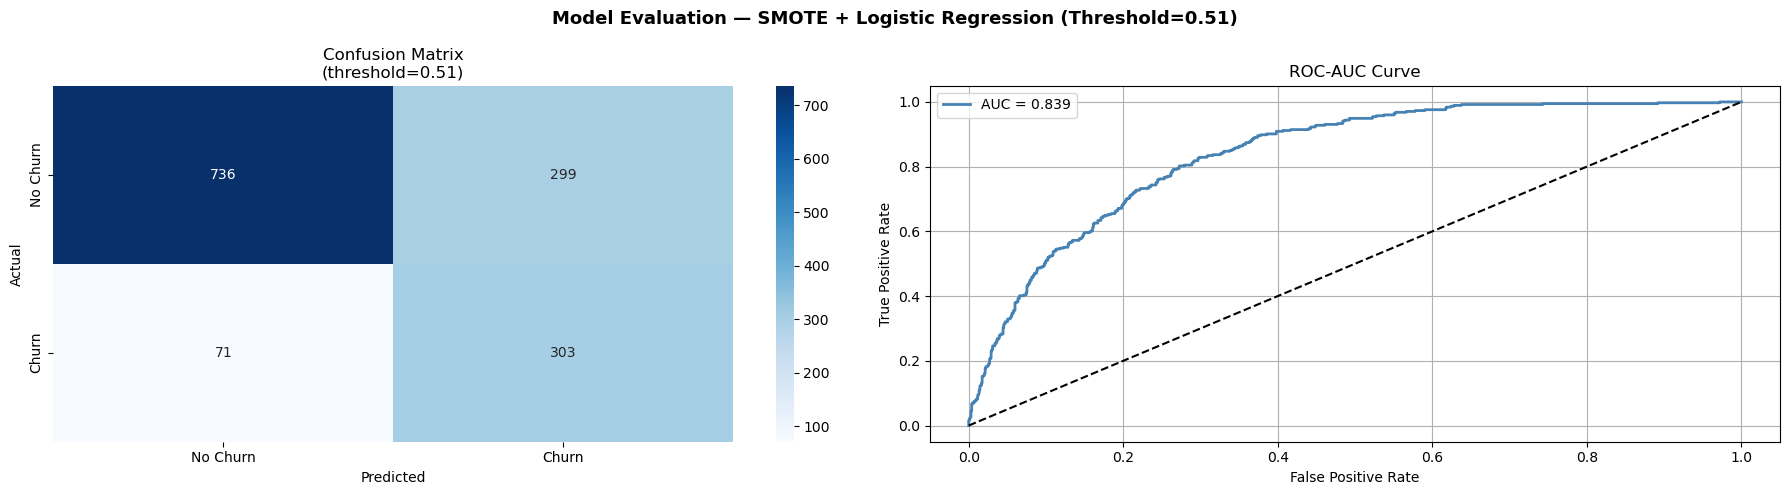

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Model Evaluation — SMOTE + Logistic Regression (Threshold=0.51)', fontsize=13, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
axes[0].set_title('Confusion Matrix\n(threshold=0.51)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc_:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC-AUC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()

# Saving the model

In [21]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [22]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!
